In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

3.26

Iter 1, weight: 3.8
Iter 2, weight: 3.08
Iter 3, weight: 2.648
Iter 4, weight: 2.3888000000000003


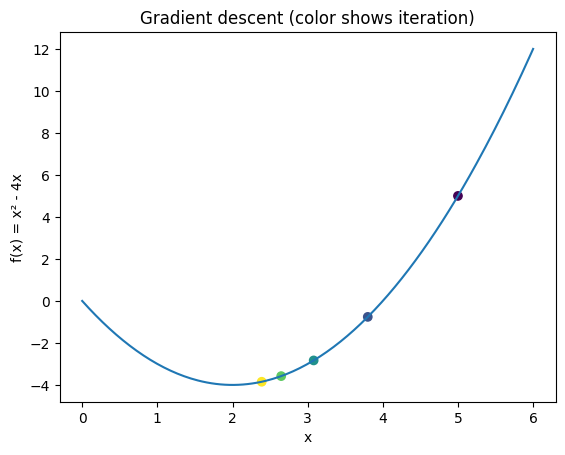

In [10]:
x0 = 5
eta = 0.2
x_history = [x0]

for i in range(4):
    gradient = 2*x0 - 4
    x0 = x0 - eta*gradient
    x_history.append(x0)
    print(f"Iter {i+1}, weight: {x0}")

x = np.linspace(0, 6, 200)
plt.plot(x, x**2 - 4*x)
plt.scatter(x_history, [v**2 - 4*v for v in x_history], c=range(len(x_history)), cmap="viridis")
plt.xlabel("x")
plt.ylabel("f(x) = x² - 4x")
plt.title("Gradient descent (color shows iteration)")
plt.show()


3.27

In [33]:
w = np.array([1, 2, -10])
x = np.array([3, 4, 1])

rawValue = np.dot(w.T, x)
label = np.sign(rawValue)
print(f"Raw value: {rawValue}, Label: {label}, if true label is -1 then the classification is {"correct" if label == -1 else "incorrect"}")

Raw value: 1, Label: 1, if true label is -1 then the classification is incorrect


3.28

In [37]:
w = np.array([-2, 1, 0])
x = np.array([2, 3, 1])
y = 1

rawValue = np.dot(w.T, x)
label = np.sign(rawValue)
print(f"Raw value: {rawValue}, Label: {label}, if true label is 1 then the classification is {"correct" if label == 1 else "incorrect"}")
w = w + y*x
print(f"New value: {np.dot(w.T, x)}, label: {np.sign(np.dot(w.T, x))}")

Raw value: -1, Label: -1, if true label is 1 then the classification is incorrect
New value: 13, label: 1


3.29

In [26]:
class Perceptron:
    def __init__(self, w_init):
        self.weight = [w_init]
        self.errorHistory = []

    def predict(self, W, x):
        return np.sign(np.dot(W.T, x))
    
    def fit(self, X, y):
        d = X.shape[0]
        N = X.shape[1]
        _iter = 0
        missPoints = []
        while True:
            mixID = np.random.permutation(N)
            for i in range(N):
                xi = X[:, mixID[i]].reshape(d, 1)
                yi = y[0, mixID[i]]
                if self.predict(self.weight[-1], xi) != yi:
                    missPoints.append(mixID[i])
                    w_new = self.weight[-1] + yi*xi
                    self.weight.append(w_new)

            _iter +=1
            print(f"iter {_iter}, current weight: {self.weight[-1]}, miss_points = {missPoints}")
            if np.array_equal(self.predict(self.weight[-1], X), y):
                break
        return (self.weight, missPoints)


iter 1, current weight: [[ 1.31780517]
 [-3.442391  ]
 [ 1.01722947]], miss_points = [np.int64(7), np.int64(14), np.int64(0), np.int64(13), np.int64(3), np.int64(10), np.int64(9)]
iter 2, current weight: [[ 3.31780517]
 [-1.46837135]
 [ 4.75651192]], miss_points = [np.int64(7), np.int64(14), np.int64(0), np.int64(13), np.int64(3), np.int64(10), np.int64(9), np.int64(0), np.int64(13), np.int64(3), np.int64(2), np.int64(12), np.int64(7)]
iter 3, current weight: [[ 3.31780517]
 [-8.1699332 ]
 [ 4.94703398]], miss_points = [np.int64(7), np.int64(14), np.int64(0), np.int64(13), np.int64(3), np.int64(10), np.int64(9), np.int64(0), np.int64(13), np.int64(3), np.int64(2), np.int64(12), np.int64(7), np.int64(14), np.int64(2), np.int64(13), np.int64(1), np.int64(7), np.int64(17), np.int64(0), np.int64(19)]
iter 4, current weight: [[ 4.31780517]
 [-9.00227656]
 [ 6.13212116]], miss_points = [np.int64(7), np.int64(14), np.int64(0), np.int64(13), np.int64(3), np.int64(10), np.int64(9), np.int64(0),

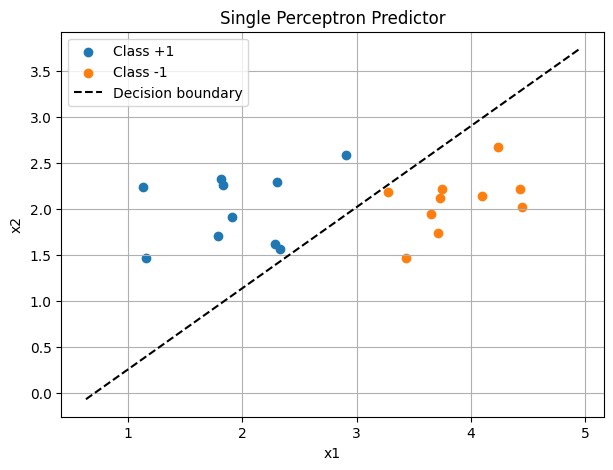

In [29]:
# randomized dataset test
N = 10
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
X0 = np.random.multivariate_normal(means[0], cov, N).T
X1 = np.random.multivariate_normal(means[1], cov, N).T

X = np.concatenate((X0, X1), axis=1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)
X = np.concatenate((np.ones((1, 2*N)), X), axis=0)

d = X.shape[0]
model = Perceptron(np.random.randn(d, 1))
(w, m) = model.fit(X, y)

def visualize():
    plt.figure(figsize=(7, 5))

    plt.scatter(X[1, y[0] == 1], X[2, y[0] == 1], label="Class +1")
    plt.scatter(X[1, y[0] == -1], X[2, y[0] == -1], label="Class -1")

    # Decision boundary: w0 + w1*x1 + w2*x2 = 0
    weights = w[-1].ravel()
    x1 = np.linspace(X[1].min() - 0.5, X[1].max() + 0.5, 200)

    if abs(weights[2]) > 1e-12:
        x2 = -(weights[0] + weights[1] * x1) / weights[2]
        plt.plot(x1, x2, "k--", label="Decision boundary")
    elif abs(weights[1]) > 1e-12:
        # Vertical boundary when the coefficient of x2 is zero
        boundary_x1 = -weights[0] / weights[1]
        plt.axvline(boundary_x1, color="k", linestyle="--", label="Decision boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Single Perceptron Predictor")
    plt.legend()
    plt.grid(True)
    plt.show()
visualize()